<a href="https://colab.research.google.com/github/ancestor9/mathematics-for-machine-learning/blob/main/scripts/w4_torch_autograd_backward.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from packaging.version import Version
assert Version(torch.__version__) >= Version("2.6.0")

## Hardware Acceleration
- colab 메뉴에서 "런타임" > "런타임 유형변경" > "T4 GPU" 설정

In [2]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cuda'

In [3]:
M = torch.tensor([[1., 2., 3.], [4., 5., 6.]])
M = M.to(device)
M.device

device(type='cuda', index=0)

In [4]:
M = torch.tensor([[1., 2., 3.], [4., 5., 6.]], device=device)
M

tensor([[1., 2., 3.],
        [4., 5., 6.]], device='cuda:0')

In [5]:
R = M @ M.T  # run some operations on the GPU
R

tensor([[14., 32.],
        [32., 77.]], device='cuda:0')

In [6]:
M = torch.rand((1000, 1000))  # on the CPU
M @ M.T  # warmup
%timeit M @ M.T

M = M.to(device)
M @ M.T  # warmup
%timeit M @ M.T

35.7 ms ± 7.55 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
721 µs ± 8.42 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


## Autograd

Consider a simple function, $f(x) = x^2$.
Calculus tells us that the derivative of this function is $f'(x)=2x$. Let's evaluate $f(5)$ and the derivative $f'(5)$ using autograd. We expect to find $f(5)=5^2=25$ and $f'(5)=2*5=10$. Let's see!

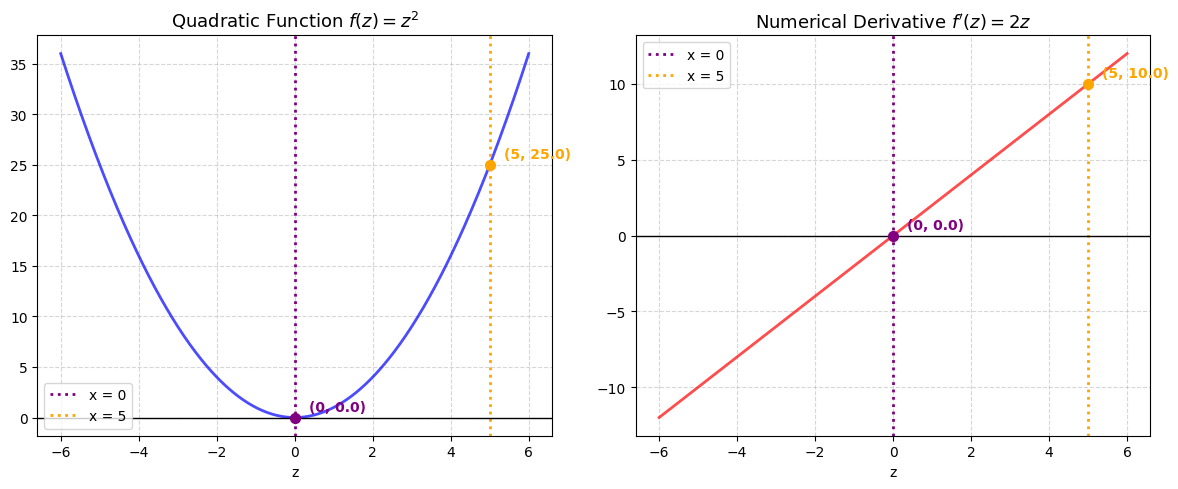

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 함수 및 미분 정의
def quadratic(z):
    return z**2

def derivative(f, z, eps=1e-6):
    return (f(z + eps) - f(z - eps)) / (2 * eps)

# 데이터 준비
z = np.linspace(-6, 6, 400) # 5를 잘 보여주기 위해 범위를 -6~6으로 확장
y = quadratic(z)
y_grad = derivative(quadratic, z)

# 시각화 설정
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
points_to_show = [0, 5]
colors = ['purple', 'orange']

# 두 그래프에 공통적으로 지점 표시 적용
for i in range(2):
    ax = axes[i]
    curr_y = y if i == 0 else y_grad
    label_prefix = 'f' if i == 0 else "f'"

    # 기본 곡선 그리기
    ax.plot(z, curr_y, color='blue' if i==0 else 'red', lw=2, alpha=0.7)

    # x=0, x=5 지점 표시
    for p, c in zip(points_to_show, colors):
        val = quadratic(p) if i == 0 else derivative(quadratic, p)
        # 수직선 추가
        ax.axvline(p, color=c, linestyle=':', lw=2, label=f'x = {p}')
        # 해당 지점에 점 찍기
        ax.scatter(p, val, color=c, s=50, zorder=5)
        # 좌표 텍스트 추가
        ax.annotate(f'({p}, {val:.1f})', (p, val), textcoords="offset points",
                    xytext=(10,5), ha='left', fontsize=10, fontweight='bold', color=c)

    ax.set_xlabel('z')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.axhline(0, color='black', lw=1)
    ax.legend()

axes[0].set_title('Quadratic Function $f(z)=z^2$', fontsize=13)
axes[1].set_title("Numerical Derivative $f'(z)=2z$", fontsize=13)

plt.tight_layout()
plt.show()

In [19]:
import torch

# 1. 값이 5.0인 스칼라 텐서를 생성
# requires_grad=True: 이 텐서(x)와 관련된 모든 연산을 추적하여
# 나중에 미분값(기울기)을 자동으로 계산하겠다고 설정하는 핵심 옵션
x = torch.tensor(5.0, requires_grad=True)
print(x)

# 2. x를 이용한 함수식 f(x) = x^2 정의
# 이때 PyTorch는 내부적으로 '제곱 연산'이 일어났음을 연산 그래프(Computation Graph)에 기록
f = x ** 2
print(f)
# grad_fn=<PowBackward0>: f가 제곱(Power) 연산을 통해 만들어졌으며,
# 역전파 시 어떤 공식으로 미분해야 할지 알고 있다는 뜻

tensor(5., requires_grad=True)
tensor(25., grad_fn=<PowBackward0>)


In [20]:
# 3. 역전파 실행 (Backpropagation)
# f라는 수식으로부터 x 방향으로 미분을 수행
# 내부적으로는 f'(x) = 2x 공식을 사용하여 x=5.0일 때의 기울기를 계산
f.backward()

# 4. 계산된 기울기(Gradient) 확인
# f를 x로 미분한 값(df/dx)이 x의 .grad 속성에 저장
x.grad

tensor(10.)

In [23]:
# 가중치 업데이트 시 사용할 보폭(Step size) 설정
learning_rate = 0.1

# 1. 자동 미분(그래프 기록) 엔진을 일시 정지하는 블록
# 업데이트 연산(x -= ...) 자체가 다시 미분 대상이 되지 않도록 연산 추적을 끈다.
with torch.no_grad():
    # 2. 경사하강법(Gradient Descent) 공식 적용
    # x = x - (학습률 * 기울기), x의 현재 값에서 기울기 방향의 반대쪽으로 이동하여 함수의 최솟값을 찾는다.
    x -= learning_rate * x.grad   # 이 연산은 미분 기록에 남지 않음 with torch.no_grad() context manager

# 3. 업데이트된 새로운 x 값 확인 (예: 5.0 - 0.1 * 10.0 = 4.0)
print(x)

tensor(2., requires_grad=True)


Alternatively, we could have used this code for the gradient descent step (but using `no_grad()` is more common for this):

In [36]:
x = torch.tensor(5.0, requires_grad=True)
f = x ** 2 # Recompute f to create a new computation graph
f.backward()

In [31]:
for _ in range(5):
    x_detached = x.detach()
    x_detached, x.grad
    print()

    x_detached -= learning_rate * x.grad
    x_detached
    print('*'*50)


**************************************************

**************************************************

**************************************************

**************************************************

**************************************************


In [32]:
x.grad.zero_()

tensor(0.)

Let's put everything together to get our training loop:

In [37]:
learning_rate = 0.1
x = torch.tensor(5.0, requires_grad=True)
for iteration in range(100):
    f = x ** 2  # forward pass
    f.backward()  # backward pass
    with torch.no_grad():
        x -= learning_rate * x.grad  # gradient descent step
    x.grad.zero_()  # reset the gradients

print(f"Iteration {iteration}: x = {x.item()}, f(x) = {f.item()}")

Iteration 99: x = 1.0185183807465137e-09, f(x) = 1.6209055950386184e-18


The variable `x` gets pushed towards 0, since that's the value that minimizes $f(x) = x^2$:

In [35]:
x

tensor(1.0185e-09, requires_grad=True)